In [1]:
print("Hello World")

Hello World


In [7]:
import pandas as pd
import numpy as np

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [9]:
print(sigmoid(0))     # should be ~0.5
print(sigmoid(10))    # close to 1
print(sigmoid(-10))   # close to 0

0.5
0.9999546021312976
4.5397868702434395e-05


In [10]:
def predict_proba(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

In [11]:
def predict(X, w, b):
    probs = predict_proba(X, w, b)
    return (probs >= 0.5).astype(int)

In [12]:
X_sample = np.array([[1, 2, 3]])
w = np.array([0.1, 0.2, 0.3])
b = 0

print(predict_proba(X_sample, w, b))
print(predict(X_sample, w, b))

[0.80218389]
[1]


In [ ]:
def compute_loss(y, y_pred):
    n = len(y)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -(1/n) * np.sum(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))

In [14]:
y = np.array([1, 0, 1])
y_pred = np.array([0.9, 0.2, 0.8])

print(compute_loss(y, y_pred))

0.18388253942874858


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Features (2D for visualization)
X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [5, 6],
    [6, 7],
    [7, 8]
])

# Labels (binary)
y = np.array([0, 0, 0, 1, 1, 1])

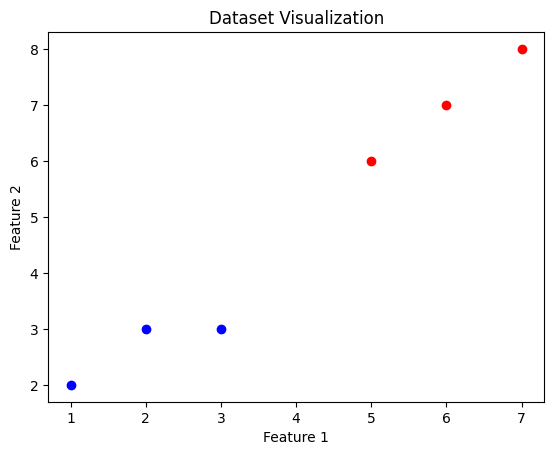

In [18]:
for i in range(len(y)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='blue')
    else:
        plt.scatter(X[i][0], X[i][1], color='red')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset Visualization")
plt.show()

In [19]:
w = np.zeros(X.shape[1])
b = 0

learning_rate = 0.01
epochs = 1000

for i in range(epochs):
    
    # Step 1: Prediction
    y_pred = predict_proba(X, w, b)
    
    # Step 2: Loss
    loss = compute_loss(y, y_pred)
    
    # Step 3: Error
    error = y_pred - y
    
    # Step 4: Gradients
    dw = (1/len(y)) * np.dot(X.T, error)
    db = (1/len(y)) * np.sum(error)
    
    # Step 5: Update
    w -= learning_rate * dw
    b -= learning_rate * db
    
    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss}")

Epoch 0, Loss: 0.6931471805599452
Epoch 100, Loss: 0.5650632964333021
Epoch 200, Loss: 0.5308984181452514
Epoch 300, Loss: 0.5002136725986941
Epoch 400, Loss: 0.4726176364467379
Epoch 500, Loss: 0.4477496684147799
Epoch 600, Loss: 0.42528416220443055
Epoch 700, Loss: 0.4049314569708374
Epoch 800, Loss: 0.3864365703486341
Epoch 900, Loss: 0.3695766682032805


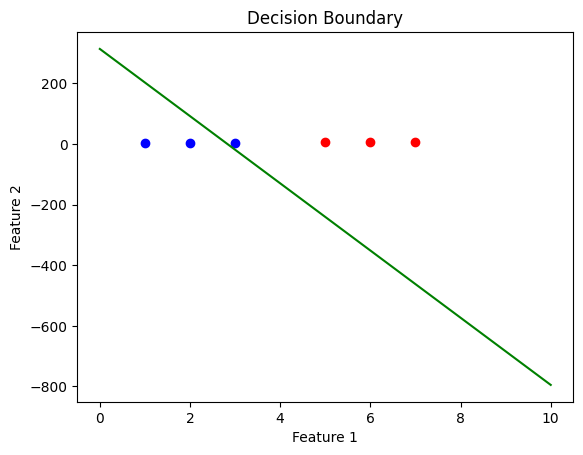

In [20]:
# Plot data again
for i in range(len(y)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='blue')
    else:
        plt.scatter(X[i][0], X[i][1], color='red')

# Decision boundary
x1 = np.linspace(0, 10, 100)

# w1*x1 + w2*x2 + b = 0 → solve for x2
x2 = -(w[0]*x1 + b) / w[1]

plt.plot(x1, x2, color='green')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")
plt.show()

In [ ]:
df = pd.read_csv("../Datasets/employee_turnover.csv")

In [ ]:
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
count,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1.350000e+03,1350.000000,1350.000000
mean,0.506386,0.487061,0.484761,0.499442,0.494884,0.509909,0.504329,0.500164,0.516149,0.506091,0.493360,0.486843,0.485767,3.291479e-01,0.240653,0.497778
std,0.291505,0.283808,0.282758,0.293013,0.289248,0.290110,0.295693,0.294835,0.295072,0.284901,0.292929,0.288342,0.285077,2.986314e-01,0.222281,0.500180
min,0.001738,0.000546,0.001545,0.000166,0.001319,0.005015,0.000424,0.000231,0.000150,0.000903,0.000491,0.001293,0.001595,2.410000e-07,0.000247,0.000000
25%,0.263051,0.238538,0.249651,0.246399,0.244162,0.263235,0.249894,0.239224,0.247978,0.269517,0.247274,0.233357,0.244944,6.114448e-02,0.058694,0.000000
50%,0.525340,0.468457,0.485414,0.495572,0.501617,0.532388,0.509448,0.499964,0.531408,0.504640,0.498490,0.475214,0.468982,2.484923e-01,0.165438,0.000000
75%,0.750987,0.724088,0.721622,0.753108,0.743938,0.761090,0.755113,0.767168,0.775888,0.761640,0.740231,0.747609,0.725870,5.479425e-01,0.367042,1.000000
max,0.998692,0.999957,0.999722,0.999931,0.997813,0.999143,0.999794,0.998365,0.999962,0.999964,0.998211,0.998330,0.999386,9.964245e-01,0.930338,1.000000


In [ ]:

# assuming df is your dataset
X = df.drop("Employee_Turnover", axis=1).values
y = df["Employee_Turnover"].values